In [1]:
import sys
sys.path.append("../src")

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from models.autoencoder import LSTMAutoencoder

In [2]:
train_data = np.load("../data/train_test_split/train.npy")
test_data = np.load("../data/train_test_split/test.npy")

print("Original train shape:", train_data.shape)
print("Original test shape:", test_data.shape)

Original train shape: (2526, 128, 128)
Original test shape: (632, 128, 128)


In [3]:
train_tensor = torch.tensor(train_data, dtype=torch.float32).permute(0, 2, 1)
test_tensor = torch.tensor(test_data, dtype=torch.float32).permute(0, 2, 1)

print("Train tensor shape:", train_tensor.shape)
print("Test tensor shape:", test_tensor.shape)

Train tensor shape: torch.Size([2526, 128, 128])
Test tensor shape: torch.Size([632, 128, 128])


In [4]:
batch_size = 32

train_dataset = TensorDataset(train_tensor)
test_dataset = TensorDataset(test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = LSTMAutoencoder(
    input_size=128,
    hidden_size=256,
    latent_size=64,
    num_layers=2
).to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
num_epochs = 15
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        reconstructed, z = model(x)
        loss = criterion(reconstructed, x)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f}")

Epoch [1/15] Loss: 0.034185
Epoch [2/15] Loss: 0.033409
Epoch [3/15] Loss: 0.032961
Epoch [4/15] Loss: 0.032922
Epoch [5/15] Loss: 0.032339
Epoch [6/15] Loss: 0.032066
Epoch [7/15] Loss: 0.032106
Epoch [8/15] Loss: 0.031724
Epoch [9/15] Loss: 0.031730
Epoch [10/15] Loss: 0.031283
Epoch [11/15] Loss: 0.031103
Epoch [12/15] Loss: 0.030731
Epoch [13/15] Loss: 0.030300
Epoch [14/15] Loss: 0.030246
Epoch [15/15] Loss: 0.029735


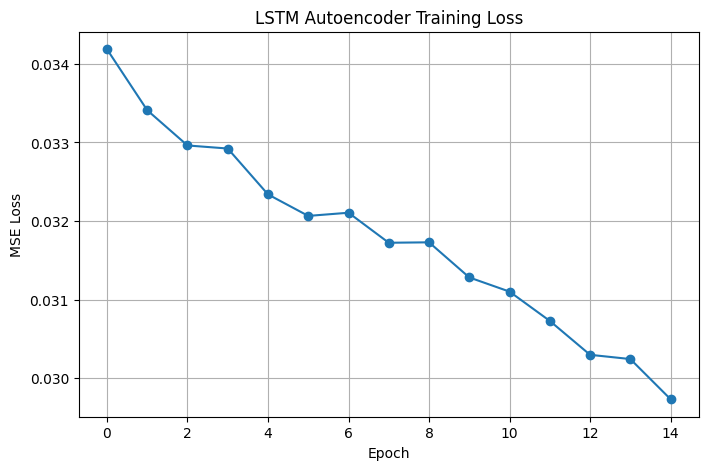

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o')
plt.title("LSTM Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [9]:
model.eval()
test_loss = 0.0

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        reconstructed, z = model(x)
        loss = criterion(reconstructed, x)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.6f}")

Test Loss: 0.029729


In [10]:
import torch

torch.save(model.state_dict(), "../outputs/checkpoints/lstm_autoencoder.pth")
print("Model saved.")

Model saved.


In [11]:
import numpy as np

np.save("../outputs/plots/task1_train_losses.npy", np.array(train_losses))
print("Loss values saved.")

Loss values saved.


In [12]:
from preprocessing.piano_roll import piano_roll_to_midi
from pathlib import Path

In [ ]:
output_dir = Path("../outputs/generated_midis/task1_autoencoder")
output_dir.mkdir(parents=True, exist_ok=True)

model.eval()

with torch.no_grad():
    for i in range(5):
        x = test_tensor[i:i+1].to(device)
        reconstructed, z = model(x)

        # shape: (1, seq_len, pitches) -> (pitches, seq_len)
        reconstructed_probs = torch.sigmoid(reconstructed)
        reconstructed_roll = reconstructed_probs.squeeze(0).cpu().numpy().T

        output_path = output_dir / f"task1_reconstructed_{i+1}.mid"
        piano_roll_to_midi(reconstructed_roll, output_path, fs=16)

        print("Saved:", output_path)

Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_1.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_2.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_3.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_4.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_5.mid


In [14]:
with torch.no_grad():
    for i in range(5):
        original_roll = test_tensor[i].cpu().numpy().T

        output_path = output_dir / f"task1_original_{i+1}.mid"
        piano_roll_to_midi(original_roll, output_path, fs=16)

        print("Saved:", output_path)

Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_1.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_2.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_3.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_4.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_5.mid


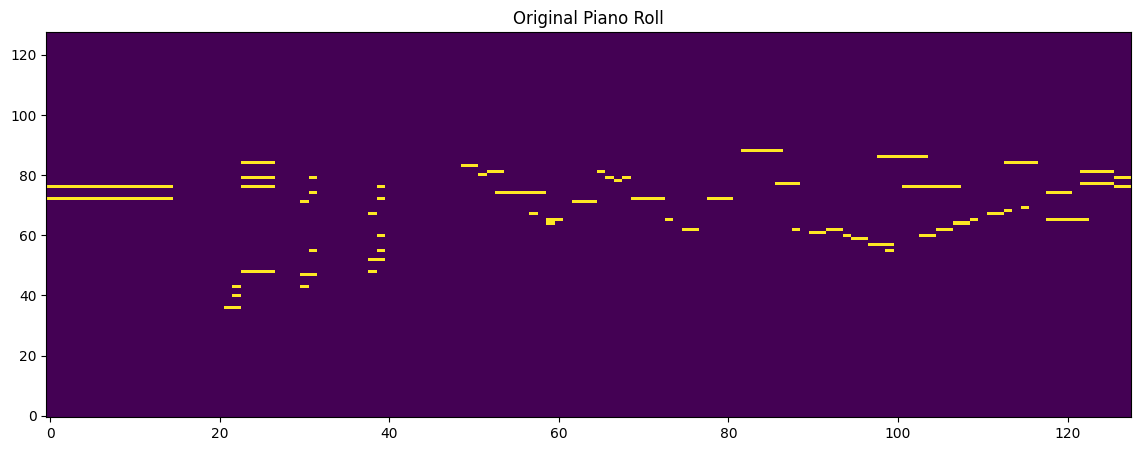

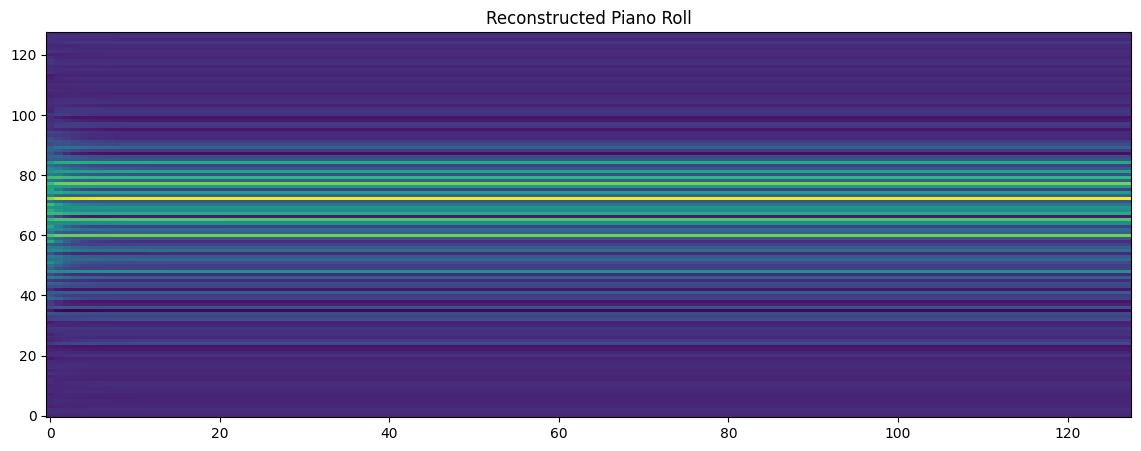

: 

In [ ]:
import matplotlib.pyplot as plt

i = 0

original = test_tensor[i].cpu().numpy().T

model.eval()
with torch.no_grad():
    x = test_tensor[i:i+1].to(device)
    reconstructed, _ = model(x)
    reconstructed = torch.sigmoid(reconstructed)
    recon = reconstructed.squeeze(0).cpu().numpy().T

plt.figure(figsize=(14, 5))
plt.imshow(original, aspect="auto", origin="lower")
plt.title("Original Piano Roll")
plt.show()

plt.figure(figsize=(14, 5))
plt.imshow(recon, aspect="auto", origin="lower")
plt.title("Reconstructed Piano Roll")
plt.show()